In [10]:
# !pip install tqdm
import matplotlib.pyplot as plt
# from utils_encoding import *
from train_pedro.make_windows2 import *
# from ipywidgets import interact
%matplotlib inline
from tqdm import tqdm
import json
import pickle

In [11]:
# parent = r"C:\__NeuroSpark_Liset_Dataset__\neurospark_mat\CNN_TRAINING_SESSIONS" # Modify this to your data path folder
# parent = r"C:\__NeuroSpark_Liset_Dataset__\neurospark_mat\Download_from_paper" # Modify this to your data path folder
# parent=r"E:\neurospark_mat\CNN_TRAINING_SESSIONS"
parent=r"D:\neurospark_mat\Download_from_paper"

bandpass=[100,250]
downsampled_fs = 30000 # Downsampled frequency
factor=downsampled_fs//1000
time_max=120
window_size=0.1
sample_ratio=0.25
scaling_factor=1
refractory=0.0003
percentile=False
fraction=(0,1)
downsample_factor=30000//downsampled_fs
overlap=int(time_max/2)
adapt=False

In [12]:
for time_max in [120]:
    overlap=int(time_max/2)
    adapt=True
    # make_up_down_threshold_present(parent, time_max, downsampled_fs, bandpass, window_size, sample_ratio, scaling_factor,
                            # refractory, factor, percentile=percentile, adapt_threshold=adapt, overlap=overlap)

In [52]:
dataset_id=0
adapt=0
saved_file=os.path.join(os.getcwd(),"train_pedro",f"adapt_{adapt}")
files=os.listdir(saved_file)
npz_file=files[dataset_id]
npz_file=os.path.join(saved_file,npz_file)
data = np.load(npz_file, allow_pickle=True)

In [51]:
spikified = data["spikified"]
filtered = data["filtered"]
thresholds_original = data["thresholds"].item()   # dict
ripples = data["ripples"]
print(thresholds_original)

{0: 0.3, 1: 0.3394, 2: 0.3514, 3: 0.43, 4: 0.3323, 5: 0.3482, 6: 0.2978, 7: 0.2863}


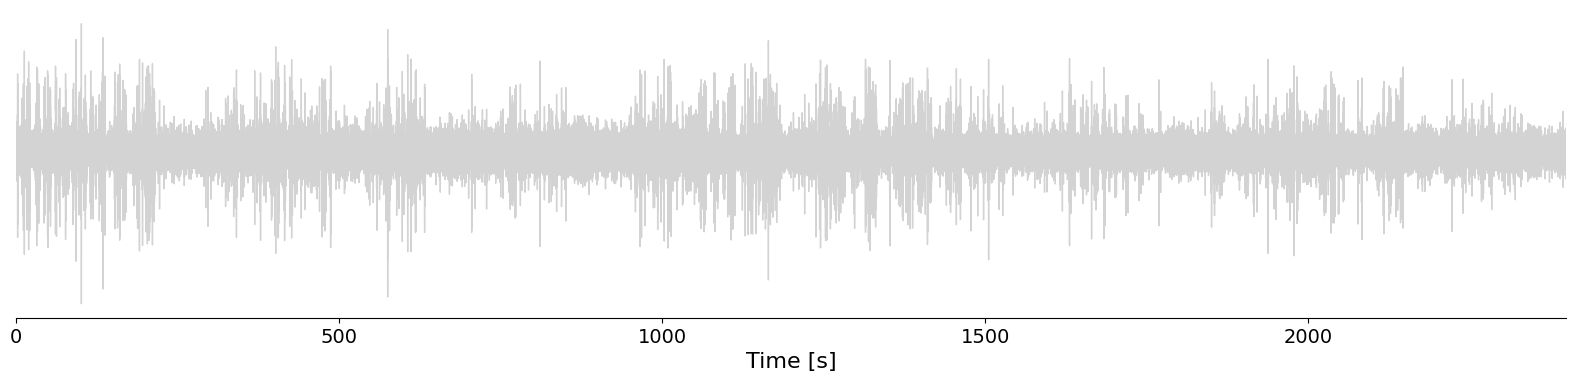

In [120]:
def plot_signal(filtered,time=1000,ripples=None,channel=0):
    fig,ax=plt.subplots(figsize=(20,4))
    samples=time*1000
    if samples>filtered.shape[0]:
        samples=filtered.shape[0]
    time=np.arange(samples)/1000
    ax.plot(time,filtered[0:samples,channel],color="lightgrey",linewidth=1)
    # plt.axhline(y=thresholds[channel], color='r', linestyle='--')
    # plt.title(f"Channel {channel} with threshold {thresholds[channel]:.2f}")
    # plt.show()
    ax.set_xlim(0,time[-1])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    ax.tick_params(axis="both", which="both",labelsize=14)
    ax.set_xlabel("Time [s]", fontsize=16)
    # ax.set_ylabel("Amplitude")
    # ax.set_title(f"Filtered signal (Channel {channel})")
    ax.set_yticks([])   
    # Overlay ripple intervals if provided
    if ripples is not None and len(ripples) > 0:
        
        for start, end in ripples:
            if start/1000>time[-1]:
                break
            ax.axvspan(start/1000, end/1000, color="yellow", alpha=0.2, label="Ripple")

    plt.show()
    return fig,ax
channel=2
fig,ax=plot_signal(filtered, time=100000, channel=channel)
save_fig=os.path.join(os.getcwd(),"figures")
os.makedirs(save_fig, exist_ok=True)
fig.savefig(os.path.join(save_fig,f"filtered_signal.png"), dpi=300, bbox_inches='tight')

In [122]:
import numpy as np
import matplotlib.pyplot as plt

def plot_thresholds(thresholds, thresholds_fixed, spikified=None,
                    time=1000, spikes=False, channel=0,
                    fs=1000, step_size=1000, around=10, ripples=None):
    """
    Plot threshold timeline for one channel.
    
    thresholds : dict
        Dict with channel -> list of adaptive thresholds.
    thresholds_fixed : dict
        Dict with channel -> float (fixed threshold reference).
    spikified : np.ndarray
        Spikified data (time, channels, 2).
    time : int
        Duration in ms to plot for spike overlay.
    spikes : bool
        If True, overlay spike train for this channel.
    channel : int
        Channel to plot.
    fs : int
        Sampling rate (Hz).
    step_size : int
        Number of samples each threshold value spans.
    around : int
        Duration in seconds to plot thresholds.
    ripples : np.ndarray or None
        Optional ripple intervals (start,end).
    """
    thr_list = thresholds[channel]         # adaptive thresholds
    original = thresholds_fixed[channel]   # fixed threshold reference
    samples=time*fs
    samples=min(samples,spikified.shape[0])
    # Adaptive threshold timeline
    time_axis = np.arange(samples) / fs
    thr_timeline = np.repeat(thr_list, step_size)

    if len(thr_timeline) < samples:
            thr_timeline = np.pad(
        thr_timeline,
        (0, samples - len(thr_timeline)),
        mode='constant',
        constant_values=thr_list[-1]   # pad with the last threshold value
    )
    
    # Restrict to "around" seconds
    thr_timeline = thr_timeline[:samples]
    time_axis = time_axis[:samples]

    # Plot
    fig, ax = plt.subplots(figsize=(20, 3))
    ax.plot(time_axis, thr_timeline, "r-", lw=2, label="Adaptive threshold")

    # Fixed threshold reference
    ax.axhline(y=original, color="blue", linestyle="--", lw=1.5, alpha=0.5,
               label=f"Fixed threshold {original:.2f}")

    # Overlay ripple intervals if provided
    if ripples is not None and len(ripples) > 0:
        for start, end in ripples:
            ax.axvspan(start/fs, end/fs, color="yellow", alpha=0.2, label="Ripple")

    # Overlay spikes (binary train)
    if spikes:
        samples = min(samples, spikified.shape[0])
        
        # Extract spike trains
        up_spike_train = spikified[:samples, channel, 0]  # UP events
        dn_spike_train = spikified[:samples, channel, 1]  # DN events
        
        # Get times of spikes
        up_spike_times = np.where(up_spike_train > 0)[0] / fs
        dn_spike_times = np.where(dn_spike_train > 0)[0] / fs
        
        # Plot vertical lines for spikes
        ax.vlines(up_spike_times, ymin=original*1.2, ymax=original*1.4,
                color="red", linewidth=0.7, label="UP spikes")
        ax.vlines(dn_spike_times, ymin=original*0.8, ymax=original*1.0,
                color="blue", linewidth=0.7, label="DN spikes")
    ax.set_xlim(0, time_axis[-1])
    # Style
    # ax.set_title(f"Threshold timeline (Channel {channel})")
    # ax.set_xlabel("Time (s)")
    # ax.set_ylabel("Threshold value")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.legend()
    ax.set_ylim(0,1)
    # ax.set_yticks([0.2,0.4,0.6,0.8,1.0])
    ax.set_yticks([0,0.5,1.0])
    ax.tick_params(axis="both", which="both",labelsize=14)
    plt.show()
    return fig,ax


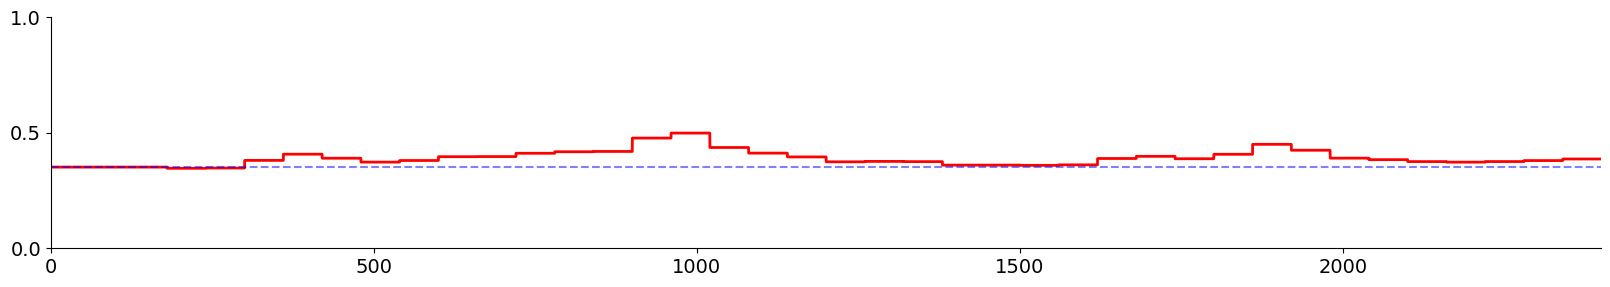

In [123]:
dataset_id=0
adapt=60
saved_file=os.path.join(os.getcwd(),"train_pedro",f"adapt_{adapt}")
files=os.listdir(saved_file)
npz_file=files[dataset_id]
npz_file=os.path.join(saved_file,npz_file)
data = np.load(npz_file, allow_pickle=True)
spikified = data["spikified"]
filtered = data["filtered"]
thresholds= data["thresholds"].item()   # dict
ripples = data["ripples"]

fig,ax=plot_thresholds(thresholds, thresholds_original, spikified,
                    time=100000, spikes=False, channel=channel,
                    fs=1000, step_size=adapt*1000, around=10, ripples=None)

fig.savefig(os.path.join(save_fig,f"thresholds_adapt_{adapt}.png"), dpi=300, bbox_inches='tight')

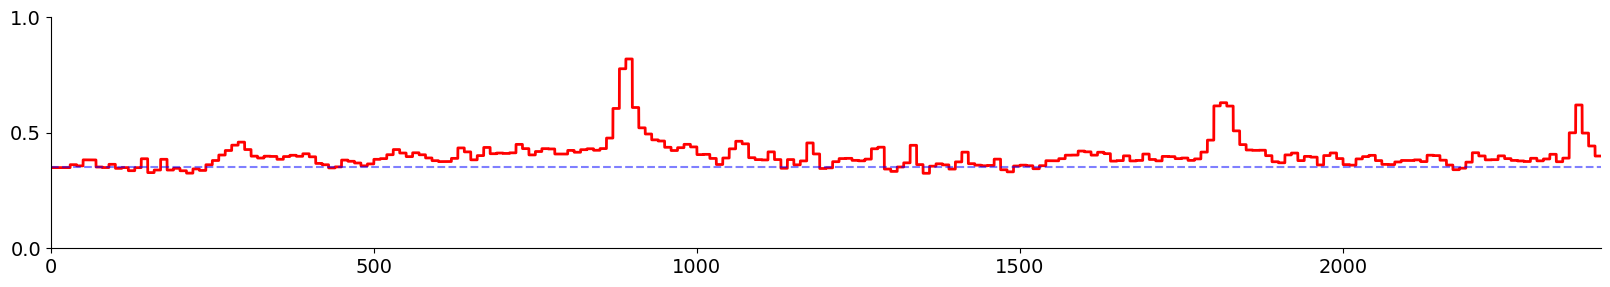

In [124]:
dataset_id=0
adapt=10
saved_file=os.path.join(os.getcwd(),"train_pedro",f"adapt_{adapt}")
files=os.listdir(saved_file)
npz_file=files[dataset_id]
npz_file=os.path.join(saved_file,npz_file)
data = np.load(npz_file, allow_pickle=True)
spikified = data["spikified"]
filtered = data["filtered"]
thresholds= data["thresholds"].item()   # dict
ripples = data["ripples"]

fig,ax=plot_thresholds(thresholds, thresholds_original, spikified,
                    time=100000, spikes=False, channel=channel,
                    fs=1000, step_size=adapt*1000, around=10, ripples=None)
fig.savefig(os.path.join(save_fig,f"thresholds_adapt_{adapt}.png"), dpi=300, bbox_inches='tight')

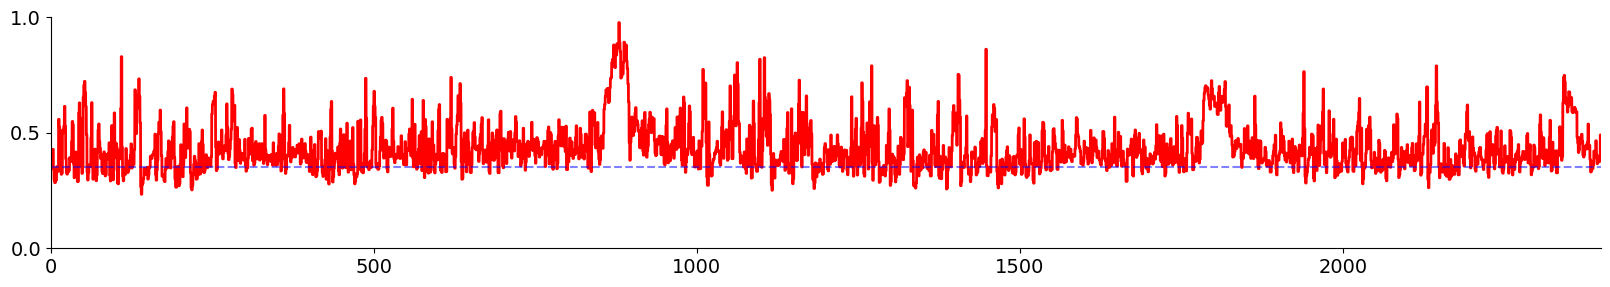

In [125]:
dataset_id=0
adapt=1
saved_file=os.path.join(os.getcwd(),"train_pedro",f"adapt_{adapt}")
files=os.listdir(saved_file)
npz_file=files[dataset_id]
npz_file=os.path.join(saved_file,npz_file)
data = np.load(npz_file, allow_pickle=True)
spikified = data["spikified"]
filtered = data["filtered"]
thresholds= data["thresholds"].item()   # dict
ripples = data["ripples"]

fig,ax=plot_thresholds(thresholds, thresholds_original, spikified,
                    time=1000000, spikes=False, channel=channel,
                    fs=1000, step_size=adapt*1000, around=10, ripples=None)
fig.savefig(os.path.join(save_fig,f"thresholds_adapt_{adapt}.png"), dpi=300, bbox_inches='tight')

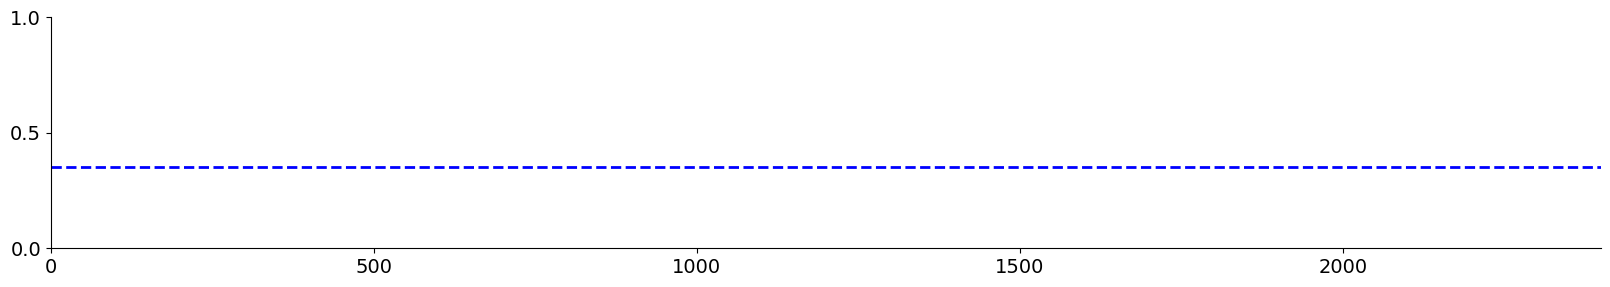

In [129]:
import numpy as np
import matplotlib.pyplot as plt

def plot_fixed_threshold(thresholds_fixed,spikified, channel=0, time=1000, fs=1000):
    """
    Plot only the fixed threshold for one channel.
    
    thresholds_fixed : dict
        Dict with channel -> float (fixed threshold reference).
    channel : int
        Channel to plot.
    time : int
        Duration in ms to plot.
    fs : int
        Sampling rate (Hz).
    """
    original = thresholds_fixed[channel]   # fixed threshold reference
    
    # Time axis
    samples = time * fs
    if samples > spikified.shape[0]:
        samples = spikified.shape[0]
    time_axis = np.arange(samples) / fs
    
    # Plot
    fig, ax = plt.subplots(figsize=(20, 3))
    ax.axhline(y=original, color="blue", linestyle="--", lw=2,
               label=f"Fixed threshold {original:.2f}")
    
    # Style (same as adaptive)
    ax.set_xlim(0, time_axis[-1])
    ax.set_ylim(0.0, 1)
    ax.set_yticks([0.0, 0.5, 1.0])
    ax.tick_params(axis="both", which="both", labelsize=14)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.set_title(f"Fixed Threshold (Channel {channel})")
    # ax.set_xlabel("Time (s)")
    # ax.set_ylabel("Threshold value")
    # ax.legend()
    plt.show()
    
    return fig, ax

fig, ax = plot_fixed_threshold(thresholds_original, spikified, channel=channel, time=100000, fs=1000)
fig.savefig(os.path.join(save_fig,f"thresholds_adapt_0.png"), dpi=300, bbox_inches='tight')